# UNIQUE input data preparation: CLint

---

The process of preparing CLint input datasets to run UNIQUE Pipeline includes the following steps:
- Importing the preprocessed CLint dataset.
- Integrating predictions from Chemprop and corresponding uncertainty estimates (ensemble variance).
- Adding and scaling GNN latent fingerprints.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

## Load CLint data

In [2]:
df = pd.read_csv('data/CLint_dataset_with_splits.csv', index_col=0)
df.head()

,Id,Structure,mol,rLM LogCLint,hLM LogCLint,Subset,split
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb760>,1.392169,0.675687,Training,train
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fba00>,2.376374,1.397349,Training,train
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbae0>,2.728062,1.458063,Training,train
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbb50>,3.243300,2.756500,Training,train
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbbc0>,3.192741,1.630824,Training,train


In [3]:
df['which_set'] = df['Subset'].copy()
df['which_set'] = df['which_set'].replace({'Training':'TRAIN', 'Calibration':'CALIBRATION', 'Validation':'TEST'})
df['which_set'].value_counts()

which_set
TRAIN          1546
CALIBRATION     926
TEST            617
Name: count, dtype: int64

Select columns

In [4]:
df = df[['Id','Structure','rLM LogCLint','hLM LogCLint','which_set']]
df.head()

,Id,Structure,rLM LogCLint,hLM LogCLint,which_set
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN


## Read model predictions

In [10]:
df_preds = pd.read_csv('CLint_model/predictions.csv')
df_preds.head()

,Unnamed: 0,Id,Structure,mol,rLM LogCLint,hLM LogCLint,Subset,split,rLM LogCLint_unc,hLM LogCLint_unc
0,0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7744711fb760>,1.365620,0.805496,Training,train,0.005797,0.002902
1,1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,<rdkit.Chem.rdchem.Mol object at 0x7744711fba00>,2.626992,1.729539,Training,train,0.006396,0.004492
2,2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbae0>,2.420001,1.637929,Training,train,0.009381,0.004681
3,3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbb50>,2.793830,1.796750,Training,train,0.005320,0.004163
4,4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,<rdkit.Chem.rdchem.Mol object at 0x7744711fbbc0>,2.914505,1.929834,Training,train,0.006007,0.004879


In [11]:
all([df.Id.iloc[x] == df_preds.Id.iloc[x] for x in range(df.shape[0])])

True

Rename columns

In [12]:
df_preds = df_preds.rename(columns={"rLM LogCLint": "predicted rLM LogCLint", "rLM LogCLint_unc": "variance rLM LogCLint",
                                    "hLM LogCLint": "predicted hLM LogCLint", "hLM LogCLint_unc": "variance hLM LogCLint"})

Select columns

In [13]:
df_preds = df_preds[['Id','predicted rLM LogCLint', 'predicted hLM LogCLint','variance rLM LogCLint','variance hLM LogCLint']]
df_preds.head()

,Id,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint
0,Mol1,1.365620,0.805496,0.005797,0.002902
1,Mol6,2.626992,1.729539,0.006396,0.004492
2,Mol8,2.420001,1.637929,0.009381,0.004681
3,Mol9,2.793830,1.796750,0.005320,0.004163
4,Mol10,2.914505,1.929834,0.006007,0.004879


Merge predictions data

In [14]:
print(df.shape)
print(df_preds.shape)
df = df.merge(df_preds, on=['Id'])
print(df.shape)
df.head()

(3089, 5)
(3089, 5)
(3089, 9)


,Id,Structure,rLM LogCLint,hLM LogCLint,which_set,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN,1.365620,0.805496,0.005797,0.002902
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN,2.626992,1.729539,0.006396,0.004492
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN,2.420001,1.637929,0.009381,0.004681
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN,2.793830,1.796750,0.005320,0.004163
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN,2.914505,1.929834,0.006007,0.004879


## Read GNN latent representations

In [17]:
df_latent = pd.read_csv('CLint_model/latent_fps_0.csv')
df_latent.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,0.042947,0.007462,0.047579,0.0,0.116529,0.022780,0.028684,0.036001,0.091790,0.070121,0.014845,0.0,0.004571,0.000000,0.038755,0.019202,0.062940,0.054078,0.054725,0.043576,0.041074,0.020916,0.015404,0.006987,0.014662,0.075633,0.051586,0.034789,0.035375,0.005831,0.035513,0.0,0.129252,0.008174,0.075027,0.009003,0.0,0.052057,0.009674,0.043961,0.045084,0.048157,0.107971,0.0,0.070282,0.054830,0.033481,0.061788,0.055283,0.046788,0.087655,0.034811,0.0,0.018289,0.077505,0.029287,0.030042,0.011747,0.000771,0.081378,0.0,0.026246,0.044533,0.042652,0.104564,0.022652,0.026176,0.025566,0.007600,0.066042,0.118821,0.010263,0.056255,0.018665,0.005984,0.017003,0.008682,0.011397,0.022515,0.032295,0.095779,0.060996,0.037653,0.037708,0.074888,0.025982,0.009370,0.145655,0.025013,0.002508,0.007867,0.044699,0.001258,0.058565,0.077364,0.028138,0.0,0.020566,0.0,0.027245,0.005950,0.022654,0.052049,0.039403,0.008294,0.000479,0.029958,0.010653,0.040441,0.014900,0.080468,0.034777,0.019047,0.045657,0.062371,0.017569,0.005715,0.006306,0.028088,0.016654,0.087001,0.011384,0.026592,0.003170,0.013799,0.095182,0.094557,0.018915,0.009835,0.042949,0.068295,0.019407,0.085094,0.056744,0.025954,0.058873,0.030375,0.060955,0.003929,0.030499,0.025819,0.016152,0.054090,0.011513,0.011022,0.086519,0.010040,0.064279,0.025998,0.058364,0.025177,0.039635,0.002414,0.068356,0.028003,0.049611,0.090449,0.034088,0.011455,0.017945,0.019566,0.025953,0.014825,0.019179,0.009796,0.035432,0.019279,0.068922,0.0,0.024181,0.042749,0.038761,0.047619,0.059882,0.048702,0.035537,0.0,0.006965,0.048018,0.001753,0.038522,0.044475,0.035890,0.087623,0.118195,0.096576,0.0,0.045273,0.073339,0.017682,0.093842,0.076275,0.037555,0.006818,0.087004,0.090691,0.002145,0.0,0.007451,0.083929,0.069772,0.064959,0.018142,0.068886,0.147739,0.071861,0.010717,0.021295,0.021816,0.013751,0.065970,0.089019,0.046063,0.043324,0.015513,0.035308,0.036649,0.020021,0.041801,0.0,0.037304,0.066067,0.0,0.0,0.049714,0.030282,0.051231,0.0,0.025513,0.034591,0.130411,0.007628,0.01

Add SMILES data

In [18]:
original_data = pd.read_csv('data/CLint_dataset_with_splits.csv', index_col=0)
smiles = original_data['Structure']
smiles

0       CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...
1       CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...
2       COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...
3       C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...
4       CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...
                              ...                        
3084            O=C(Nc1ccc(CN2CCCCC2)cc1)c1ccnc2[nH]cnc12
3085       NC(=O)c1cnc(N2CCc3[nH]nc(C(F)(F)F)c3C2)c(Cl)c1
3086             CC1CC(N)CCN1C(=O)c1cc(N2CCNC2=O)c(F)cc1F
3087                CCN1CCOC(C(=O)N2CCC(c3cn[nH]c3)CC2)C1
3088           CCCCCCCCc1ccc(CC[C@](N)(CO)COP(=O)(O)O)cc1
Name: Structure, Length: 3089, dtype: object

In [19]:
print(df_latent.shape)
print(smiles.shape)
df_latent = pd.concat([smiles, df_latent], axis=1)
print(df_latent.shape)
df_latent.head()

(3089, 300)
(3089,)
(3089, 301)


,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.042947,0.007462,0.047579,0.0,0.116529,0.022780,0.028684,0.036001,0.091790,0.070121,0.014845,0.0,0.004571,0.000000,0.038755,0.019202,0.062940,0.054078,0.054725,0.043576,0.041074,0.020916,0.015404,0.006987,0.014662,0.075633,0.051586,0.034789,0.035375,0.005831,0.035513,0.0,0.129252,0.008174,0.075027,0.009003,0.0,0.052057,0.009674,0.043961,0.045084,0.048157,0.107971,0.0,0.070282,0.054830,0.033481,0.061788,0.055283,0.046788,0.087655,0.034811,0.0,0.018289,0.077505,0.029287,0.030042,0.011747,0.000771,0.081378,0.0,0.026246,0.044533,0.042652,0.104564,0.022652,0.026176,0.025566,0.007600,0.066042,0.118821,0.010263,0.056255,0.018665,0.005984,0.017003,0.008682,0.011397,0.022515,0.032295,0.095779,0.060996,0.037653,0.037708,0.074888,0.025982,0.009370,0.145655,0.025013,0.002508,0.007867,0.044699,0.001258,0.058565,0.077364,0.028138,0.0,0.020566,0.0,0.027245,0.005950,0.022654,0.052049,0.039403,0.008294,0.000479,0.029958,0.010653,0.040441,0.014900,0.080468,0.034777,0.019047,0.045657,0.062371,0.017569,0.005715,0.006306,0.028088,0.016654,0.087001,0.011384,0.026592,0.003170,0.013799,0.095182,0.094557,0.018915,0.009835,0.042949,0.068295,0.019407,0.085094,0.056744,0.025954,0.058873,0.030375,0.060955,0.003929,0.030499,0.025819,0.016152,0.054090,0.011513,0.011022,0.086519,0.010040,0.064279,0.025998,0.058364,0.025177,0.039635,0.002414,0.068356,0.028003,0.049611,0.090449,0.034088,0.011455,0.017945,0.019566,0.025953,0.014825,0.019179,0.009796,0.035432,0.019279,0.068922,0.0,0.024181,0.042749,0.038761,0.047619,0.059882,0.048702,0.035537,0.0,0.006965,0.048018,0.001753,0.038522,0.044475,0.035890,0.087623,0.118195,0.096576,0.0,0.045273,0.073339,0.017682,0.093842,0.076275,0.037555,0.006818,0.087004,0.090691,0.002145,0.0,0.007451,0.083929,0.069772,0.064959,0.018142,0.068886,0.147739,0.071861,0.010717,0.021295,0.021816,0.013751,0.065970,0.089019,0.046063,0.043324,0.015513,0.035308,0.036649,0.020021,0.041801,0.0,0.037304,0.066067,0.0,0.0,0.049714,0.

In [20]:
# Drop duplicated latent profiles
df_latent = df_latent.drop_duplicates()
df_latent.shape

(3089, 301)

Inspect feature distributions and outlier identification

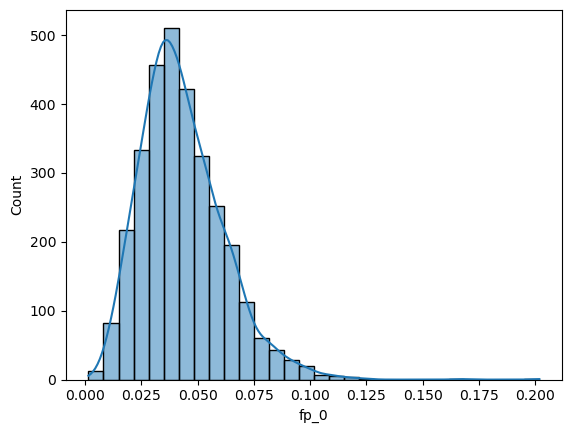

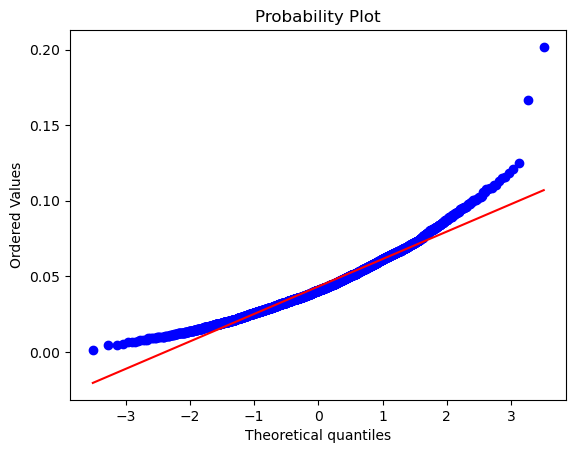

In [21]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# inspect the first latent feature
feature = df_latent['fp_0']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

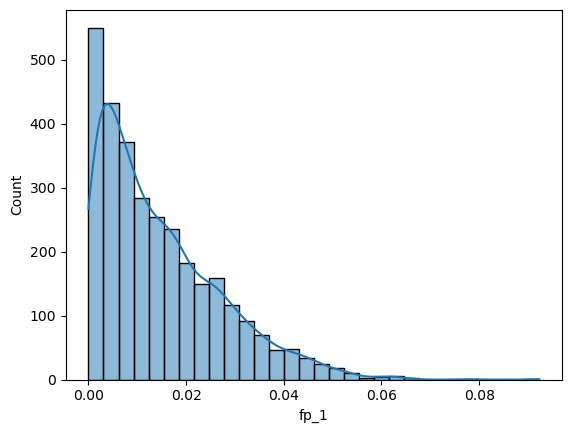

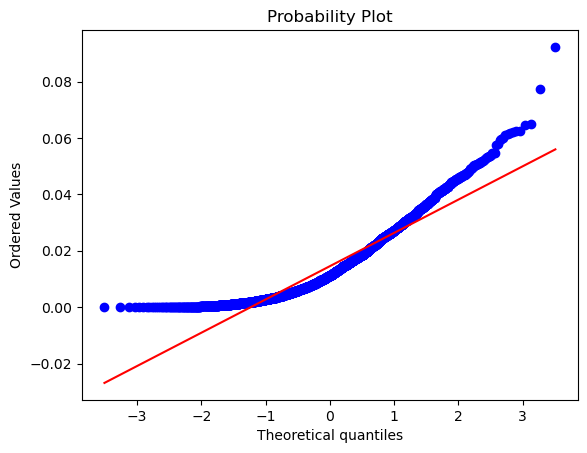

In [22]:
# inspect the second latent feature
feature = df_latent['fp_1']
# histogram
sns.histplot(feature, kde=True, bins=30)
plt.show()
# Q-Q plot
stats.probplot(feature, dist="norm", plot=plt)
plt.show()

In [23]:
print(df_latent['fp_0'].skew(axis=0, skipna=True))
print(df_latent['fp_1'].skew())

0.9977481321615602
1.1544672921375991


In [24]:
def detect_outliers(df, feature):
    zscores = (df[feature] - df[feature].mean())/df[feature].std(ddof=0)

    lower_outliers = df[zscores < -3]
    upper_outliers = df[zscores > 3]

    lower_percent = len(lower_outliers) / len(df) * 100
    upper_percent = len(upper_outliers) / len(df) * 100

    return lower_percent, upper_percent

In [25]:
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_0')
print(lower_percent, upper_percent)
lower_percent, upper_percent = detect_outliers(df_latent, 'fp_1')
print(lower_percent, upper_percent)

0.0 0.8416963418582066
0.0 0.8740692780835222


Add latent fingerprint descriptors in a single column and scale them

In [26]:
df_latent['latent_fp'] = [np.array(df_latent.iloc[x, np.where(['fp_' in col for col in df_latent.columns])[0]]) for x in range(df_latent.shape[0])]
df_latent.head()

,Structure,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,fp_10,fp_11,fp_12,fp_13,fp_14,fp_15,fp_16,fp_17,fp_18,fp_19,fp_20,fp_21,fp_22,fp_23,fp_24,fp_25,fp_26,fp_27,fp_28,fp_29,fp_30,fp_31,fp_32,fp_33,fp_34,fp_35,fp_36,fp_37,fp_38,fp_39,fp_40,fp_41,fp_42,fp_43,fp_44,fp_45,fp_46,fp_47,fp_48,fp_49,fp_50,fp_51,fp_52,fp_53,fp_54,fp_55,fp_56,fp_57,fp_58,fp_59,fp_60,fp_61,fp_62,fp_63,fp_64,fp_65,fp_66,fp_67,fp_68,fp_69,fp_70,fp_71,fp_72,fp_73,fp_74,fp_75,fp_76,fp_77,fp_78,fp_79,fp_80,fp_81,fp_82,fp_83,fp_84,fp_85,fp_86,fp_87,fp_88,fp_89,fp_90,fp_91,fp_92,fp_93,fp_94,fp_95,fp_96,fp_97,fp_98,fp_99,fp_100,fp_101,fp_102,fp_103,fp_104,fp_105,fp_106,fp_107,fp_108,fp_109,fp_110,fp_111,fp_112,fp_113,fp_114,fp_115,fp_116,fp_117,fp_118,fp_119,fp_120,fp_121,fp_122,fp_123,fp_124,fp_125,fp_126,fp_127,fp_128,fp_129,fp_130,fp_131,fp_132,fp_133,fp_134,fp_135,fp_136,fp_137,fp_138,fp_139,fp_140,fp_141,fp_142,fp_143,fp_144,fp_145,fp_146,fp_147,fp_148,fp_149,fp_150,fp_151,fp_152,fp_153,fp_154,fp_155,fp_156,fp_157,fp_158,fp_159,fp_160,fp_161,fp_162,fp_163,fp_164,fp_165,fp_166,fp_167,fp_168,fp_169,fp_170,fp_171,fp_172,fp_173,fp_174,fp_175,fp_176,fp_177,fp_178,fp_179,fp_180,fp_181,fp_182,fp_183,fp_184,fp_185,fp_186,fp_187,fp_188,fp_189,fp_190,fp_191,fp_192,fp_193,fp_194,fp_195,fp_196,fp_197,fp_198,fp_199,fp_200,fp_201,fp_202,fp_203,fp_204,fp_205,fp_206,fp_207,fp_208,fp_209,fp_210,fp_211,fp_212,fp_213,fp_214,fp_215,fp_216,fp_217,fp_218,fp_219,fp_220,fp_221,fp_222,fp_223,fp_224,fp_225,fp_226,fp_227,fp_228,fp_229,fp_230,fp_231,fp_232,fp_233,fp_234,fp_235,fp_236,fp_237,fp_238,fp_239,fp_240,fp_241,fp_242,fp_243,fp_244,fp_245,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255,fp_256,fp_257,fp_258,fp_259,fp_260,fp_261,fp_262,fp_263,fp_264,fp_265,fp_266,fp_267,fp_268,fp_269,fp_270,fp_271,fp_272,fp_273,fp_274,fp_275,fp_276,fp_277,fp_278,fp_279,fp_280,fp_281,fp_282,fp_283,fp_284,fp_285,fp_286,fp_287,fp_288,fp_289,fp_290,fp_291,fp_292,fp_293,fp_294,fp_295,fp_296,fp_297,fp_298,fp_299,latent_fp
0,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,0.042947,0.007462,0.047579,0.0,0.116529,0.022780,0.028684,0.036001,0.091790,0.070121,0.014845,0.0,0.004571,0.000000,0.038755,0.019202,0.062940,0.054078,0.054725,0.043576,0.041074,0.020916,0.015404,0.006987,0.014662,0.075633,0.051586,0.034789,0.035375,0.005831,0.035513,0.0,0.129252,0.008174,0.075027,0.009003,0.0,0.052057,0.009674,0.043961,0.045084,0.048157,0.107971,0.0,0.070282,0.054830,0.033481,0.061788,0.055283,0.046788,0.087655,0.034811,0.0,0.018289,0.077505,0.029287,0.030042,0.011747,0.000771,0.081378,0.0,0.026246,0.044533,0.042652,0.104564,0.022652,0.026176,0.025566,0.007600,0.066042,0.118821,0.010263,0.056255,0.018665,0.005984,0.017003,0.008682,0.011397,0.022515,0.032295,0.095779,0.060996,0.037653,0.037708,0.074888,0.025982,0.009370,0.145655,0.025013,0.002508,0.007867,0.044699,0.001258,0.058565,0.077364,0.028138,0.0,0.020566,0.0,0.027245,0.005950,0.022654,0.052049,0.039403,0.008294,0.000479,0.029958,0.010653,0.040441,0.014900,0.080468,0.034777,0.019047,0.045657,0.062371,0.017569,0.005715,0.006306,0.028088,0.016654,0.087001,0.011384,0.026592,0.003170,0.013799,0.095182,0.094557,0.018915,0.009835,0.042949,0.068295,0.019407,0.085094,0.056744,0.025954,0.058873,0.030375,0.060955,0.003929,0.030499,0.025819,0.016152,0.054090,0.011513,0.011022,0.086519,0.010040,0.064279,0.025998,0.058364,0.025177,0.039635,0.002414,0.068356,0.028003,0.049611,0.090449,0.034088,0.011455,0.017945,0.019566,0.025953,0.014825,0.019179,0.009796,0.035432,0.019279,0.068922,0.0,0.024181,0.042749,0.038761,0.047619,0.059882,0.048702,0.035537,0.0,0.006965,0.048018,0.001753,0.038522,0.044475,0.035890,0.087623,0.118195,0.096576,0.0,0.045273,0.073339,0.017682,0.093842,0.076275,0.037555,0.006818,0.087004,0.090691,0.002145,0.0,0.007451,0.083929,0.069772,0.064959,0.018142,0.068886,0.147739,0.071861,0.010717,0.021295,0.021816,0.013751,0.065970,0.089019,0.046063,0.043324,0.015513,0.035308,0.036649,0.020021,0.041801,0.0,0.037304,0.066067,0.0,0.0,0

Merge latent representations

In [27]:
set(df.Structure) == set(df_latent.Structure)

True

In [28]:
print(df.shape)
print(df_latent.shape)
df = df.merge(df_latent[['Structure','latent_fp']], on=['Structure'])
print(df.shape)
df.head()

(3089, 9)
(3089, 302)
(3089, 10)


,Id,Structure,rLM LogCLint,hLM LogCLint,which_set,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint,latent_fp
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN,1.365620,0.805496,0.005797,0.002902,"[0.04294698, 0.007462278, 0.047579173, 0.0, 0...."
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN,2.626992,1.729539,0.006396,0.004492,"[0.066528134, 0.006780972, 0.08804243, 0.0, 0...."
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN,2.420001,1.637929,0.009381,0.004681,"[0.09250086, 0.022525191, 0.14258464, 0.0, 0.0..."
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN,2.793830,1.796750,0.005320,0.004163,"[0.05284936, 0.010573186, 0.106758974, 0.0, 0...."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN,2.914505,1.929834,0.006007,0.004879,"[0.03821383, 0.00634887, 0.09948188, 0.0, 0.09..."


Given that most of latent fingerprint features show a positively skewed distribution (which does not follow a Gaussian distribution) and have a significant percentage of outliers (more than 0.3% as determined from the Z-score detection method), we employed a Robust Scaler to perform feature transformation, rather than using a Standard Scaler.

In [29]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit(np.array([np.array(x) for x in df[df.which_set == 'TRAIN'].latent_fp]))
df['latent_fp_scaled'] = [list(i) for i in scaler.transform(np.array([np.array(x) for x in df.latent_fp]))]
df = df.drop(columns='latent_fp')
df.head()

,Id,Structure,rLM LogCLint,hLM LogCLint,which_set,predicted rLM LogCLint,predicted hLM LogCLint,variance rLM LogCLint,variance hLM LogCLint,latent_fp_scaled
0,Mol1,CNc1cc(Nc2cccn(-c3ccccn3)c2=O)nn2c(C(=O)N[C@@H...,1.392169,0.675687,TRAIN,1.365620,0.805496,0.005797,0.002902,"[0.10311670264896901, -0.21199927645558628, -0..."
1,Mol6,CC#CC(=O)N[C@H]1CCCN(c2c(F)cc(C(N)=O)c3[nH]c(C...,2.376374,1.397349,TRAIN,2.626992,1.729539,0.006396,0.004492,"[1.061454400547144, -0.25124417338586086, 0.29..."
2,Mol8,COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2...,2.728062,1.458063,TRAIN,2.420001,1.637929,0.009381,0.004681,"[2.1169855438906833, 0.6556614635858821, 1.729..."
3,Mol9,C=CC(=O)N1CCC[C@@H](n2nc(-c3ccc(Oc4ccccc4)cc3)...,3.243300,2.756500,TRAIN,2.793830,1.796750,0.005320,0.004163,"[0.5055492575999662, -0.03280334420258022, 0.7..."
4,Mol10,CC(C)NC(=O)COc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3...,3.192741,1.630824,TRAIN,2.914505,1.929834,0.006007,0.004879,"[-0.08923843293119608, -0.27613430858702664, 0..."


## Save final datasets

Save the generated UNIQUE input dataset for each endpoint into a separate CSV file.

In [30]:
for endpoint in ['rLM LogCLint', 'hLM LogCLint']:

    print(f'\n{endpoint}')
    df_endpoint = df[['Id', 'Structure', f'{endpoint}', f'predicted {endpoint}', f'variance {endpoint}', 'which_set', 'latent_fp_scaled']]
    df_endpoint.columns = ['Id', 'Structure', 'labels', 'predictions', 'variance', 'which_set', 'latent_fp_scaled']

    print(df_endpoint.shape)
    df_endpoint = df_endpoint.dropna()
    print(df_endpoint.shape)

    print(df_endpoint.which_set.value_counts())
    print(df_endpoint.which_set.value_counts()/df_endpoint.which_set.value_counts().sum() * 100)

    df_endpoint.to_csv(f'unique_input_data/{endpoint}_unique_input_data.csv')


rLM LogCLint
(3089, 7)
(3051, 7)
which_set
TRAIN          1527
CALIBRATION     915
TEST            609
Name: count, dtype: int64
which_set
TRAIN          50.049164
CALIBRATION    29.990167
TEST           19.960669
Name: count, dtype: float64

hLM LogCLint
(3089, 7)
(3084, 7)
which_set
TRAIN          1544
CALIBRATION     924
TEST            616
Name: count, dtype: int64
which_set
TRAIN          50.064851
CALIBRATION    29.961089
TEST           19.974060
Name: count, dtype: float64
